# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [ ]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())




Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [8]:
# Task 1


df["pct_change"] = (df["attend_h1_2026"] - df["attend_h1_2025"]) / df["attend_h1_2025"] * 100

display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]

print(f"Largest fall: Triage {largest_fall['triage']} "
      f"({largest_fall['triage_name']}), {largest_fall['pct_change']:.2f}%")
print(f"Largest rise: Triage {largest_rise['triage']} "
      f"({largest_rise['triage_name']}), {largest_rise['pct_change']:.2f}%")

triage_4_5 = df[df["triage"].isin([4, 5])]
attend_2025 = triage_4_5["attend_h1_2025"].sum()
attend_2026 = triage_4_5["attend_h1_2026"].sum()
combined_pct_change = (attend_2026 - attend_2025) / attend_2025 * 100

print(f"Triage 4+5 combined percentage change: {combined_pct_change:.2f}%")
#
# YOUR CODE BELOW





,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Triage 5 (Non-urgent), -20.00%
Largest rise: Triage 1 (Critical), 5.00%
Triage 4+5 combined percentage change: -10.00%


In [1]:
# Task 1 note
task1_note = """
REPLACE: 1–2 sentences.
- Triage 1–2 mainly rose or fell?rise
- Triage 4–5 mainly rose or fell?fall
- Short link to the A&E claim (lower-urgency down; critical/emergency protected).All critical and emergency attendance are risen.Meanwhile the less severe cases are fallen.

"""
print(task1_note)




REPLACE: 1–2 sentences.
- Triage 1–2 mainly rose or fell?rise
- Triage 4–5 mainly rose or fell?fall
- Short link to the A&E claim (lower-urgency down; critical/emergency protected).All critical and emergency attendance are risen.Meanwhile the less severe cases are fallen.




## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


KeyError: 'pct_change'

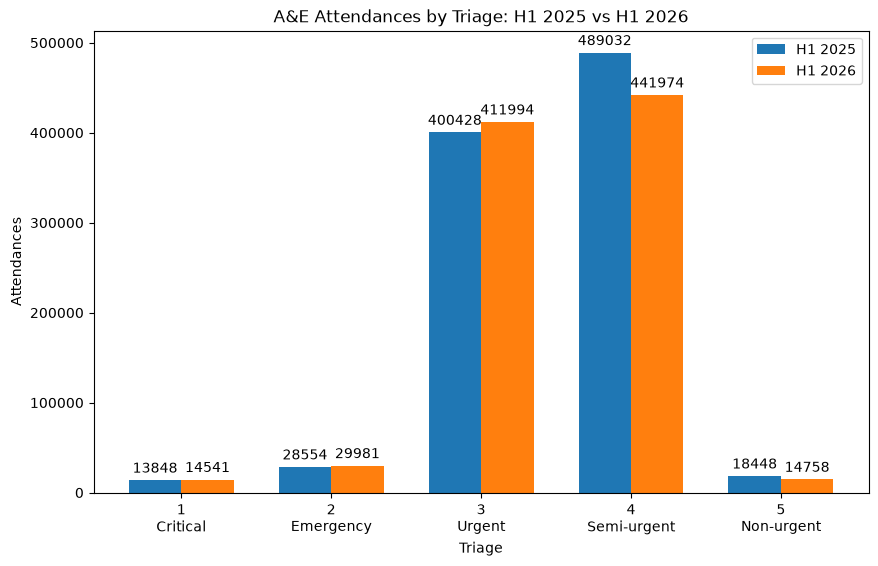

In [ ]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input:
#The Triagle records of attend2025 h1 and attend 2026h1
# Process:
#   Write Python code to covert the 2 set of data(5 groups each) into a 10-grouped bar chart,highlight the percentage change of the variance .
#
# Output:
#bar chart
#
# YOUR CODE BELOW
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())

x = range(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_2025 = ax.bar(
    [i - width / 2 for i in x],
    df["attend_h1_2025"],
    width,
    label="H1 2025"
)
bars_2026 = ax.bar(
    [i + width / 2 for i in x],
    df["attend_h1_2026"],
    width,
    label="H1 2026"
)

ax.set_xlabel("Triage")
ax.set_ylabel("Attendances")
ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{triage}\n{name}" for triage, name in zip(df["triage"], df["triage_name"])]
)
ax.legend()

for bars in (bars_2025, bars_2026):
    ax.bar_label(bars, padding=3, fmt="%.0f")

for i, change in enumerate(df["pct_change"]):
    top = max(df.loc[i, "attend_h1_2025"], df.loc[i, "attend_h1_2026"])
    ax.text(
        i,
        top * 1.05,
        f"{change:+.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.margins(y=0.15)
plt.tight_layout()
plt.show()



## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [ ]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
triagle 4 in 2025 had 489032 attendances.

3a GAP (1 point):
The number is reduced in 2026 by 47058 after the fee reform.
"""

task3b = """
3b:In early 2026, Hong Kong implemented a public healthcare fee reform that successfully reduced overall 
A&E attendances by 3.9%.It may implies the reduction of A&E usage.
REPLACE: 2–4 sentences on how well the claim is supported by the published evidence.
"""

print(task3a)
print("---")
print(task3b)



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
